# Predictive Modelling — LAI Adherence Trajectory
**TFG Biomedical Engineering | Hospital Clínic de Barcelona / FRCB-IDIBAPS**

This notebook builds a multiclass classifier to predict which of the four adherence trajectory clusters (k=4) a patient will belong to, using only pre-switch information available at the time of the clinical decision.

**Sections:**
1. Imports and data loading
2. Feature matrix construction
3. Model training and hyperparameter optimisation (Optuna)
4. Feature importance analysis
5. SHAP analysis (non-PDC features)
6. PDC trajectory plots by drug type and cluster
7. Prospective application to oral-only non-switcher patients

---
## 1. Imports and Data Loading

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
import shap
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── File paths — update if needed ─────────────────────────────────────────────
PATH_PDC     = r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_monthly_wide_clusters.csv'
PATH_ANNUAL  = r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\pdc_per_patient_year.csv'
PATH_SOCIO   = r'C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\cohort_schizophrenia_sociodemografica.csv'
PATH_URG     = r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\urg_epi_dx_proc_schizophrenia.csv'
PATH_SMH     = r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\smh_epi_dx_proc_schizophrenia.csv'
PATH_SMA     = r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\sma_cap_dx_schizophrenia.csv'
PATH_T25     = r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\25_taula_farmacs_mhda_2010_2019_Final.csv'
PATH_T23     = r'C:\Users\laiar\Desktop\DATOS_PADRIS_nets\23_antipsicotics_dispensats.csv'

# ── Load files ────────────────────────────────────────────────────────────────
pdc    = pd.read_csv(PATH_PDC)
annual = pd.read_csv(PATH_ANNUAL)
socio  = pd.read_csv(PATH_SOCIO)
urg    = pd.read_csv(PATH_URG)
smh    = pd.read_csv(PATH_SMH)
sma    = pd.read_csv(PATH_SMA)
t25    = pd.read_csv(PATH_T25)
t23    = pd.read_csv(PATH_T23, low_memory=False)

# Fix SMA date column encoding issue
sma = sma.rename(columns={sma.columns[2]: 'dat_ini'})
sma['dat_ini'] = pd.to_datetime(sma['dat_ini'], format='%Y%m%d')

# Parse dates
t25['Any_Mes'] = pd.to_datetime(t25['Any_Mes'], format='%Y%m')
t23['Any_Mes'] = pd.to_datetime(t23['Any_Mes'], format='%Y%m')

print(f"PDC cohort: {len(pdc)} patients")
print(f"Cluster distribution:\n{pdc['cluster_k4'].value_counts().sort_index()}")

PDC cohort: 1025 patients
Cluster distribution:
cluster_k4
0    321
1    319
2    187
3    198
Name: count, dtype: int64


---
## 2. Feature Matrix Construction

All features are derived exclusively from pre-switch information to ensure the model is applicable prospectively.

In [4]:
# ── 2.1 Pre-switch PDC + target ───────────────────────────────────────────────
pre_cols = [f'Month_{i}' for i in range(-12, 0)]
post_cols = [f'Month_{i}' for i in range(1, 13)]
features = pdc[['idCas', 'cluster_k4'] + pre_cols].copy()

# ── 2.2 Switch date and year ──────────────────────────────────────────────────
switch_info = (
    annual[annual['switcher'] == True][['idCas', 'first_lai_date']]
    .drop_duplicates('idCas')
)
switch_info['first_lai_date'] = pd.to_datetime(switch_info['first_lai_date'])
switch_info['switch_year'] = switch_info['first_lai_date'].dt.year
features = features.merge(
    switch_info[['idCas', 'first_lai_date', 'switch_year']], on='idCas', how='left'
)
switch_dates = features[['idCas', 'first_lai_date']].copy()

# ── 2.3 Pre-switch psychiatric visit counts ───────────────────────────────────
def count_preswitch_visits(visit_df, date_col, switch_dates, label):
    visit_df = visit_df.copy()
    visit_df[date_col] = pd.to_datetime(visit_df[date_col])
    merged = visit_df.merge(switch_dates, on='idCas', how='inner')
    pre = merged[
        (merged[date_col] >= merged['first_lai_date'] - pd.DateOffset(months=12)) &
        (merged[date_col] <  merged['first_lai_date'])
    ]
    return pre.groupby('idCas').size().reset_index(name=f'n_{label}_pre')

urg_counts = count_preswitch_visits(urg, 'dat_ini', switch_dates, 'urg')
smh_counts = count_preswitch_visits(smh, 'dat_ini', switch_dates, 'smh')
sma_counts = count_preswitch_visits(sma, 'dat_ini', switch_dates, 'sma')

for counts in [urg_counts, smh_counts, sma_counts]:
    features = features.merge(counts, on='idCas', how='left')
features[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']] = \
    features[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']].fillna(0)

# ── 2.4 Sociodemographics ─────────────────────────────────────────────────────
features = features.merge(
    socio[['idCas', 'SEXE1', 'EDAT_rang', 'NIVSOC', 'never_smoker', 'current_smoker', 'ex_smoker']],
    on='idCas', how='left'
)
features[['never_smoker', 'current_smoker', 'ex_smoker']] = \
    features[['never_smoker', 'current_smoker', 'ex_smoker']].fillna(0)

# ── 2.5 Oral antipsychotic type pre-switch ────────────────────────────────────
t23_cohort = t23.merge(switch_dates, on='idCas', how='inner')
t23_pre = t23_cohort[t23_cohort['Any_Mes'] < t23_cohort['first_lai_date']]

most_common_oral = (
    t23_pre.groupby(['idCas', 'DES_HIS_Producte'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates('idCas')[['idCas', 'DES_HIS_Producte']]
)
most_common_oral.columns = ['idCas', 'main_oral_product']

def classify_oral(name):
    name = str(name).upper()
    if   'RISPERIDONA' in name or 'RISPERDAL' in name:  return 'risperidone'
    elif 'OLANZAPINA'  in name or 'ZYPREXA'   in name:  return 'olanzapine'
    elif 'QUETIAPINA'  in name or 'SEROQUEL'  in name:  return 'quetiapine'
    elif 'ARIPIPRAZOL' in name or 'ABILIFY'   in name:  return 'aripiprazole'
    elif 'PALIPERIDONA' in name or 'INVEGA'   in name:  return 'paliperidone'
    elif 'CLOZAPINA'   in name or 'LEPONEX'   in name:  return 'clozapine'
    elif 'HALOPERIDOL' in name:                          return 'haloperidol'
    elif 'AMISULPIRIDA' in name:                         return 'amisulpride'
    elif 'SULPIRIDA'   in name:                          return 'sulpiride'
    elif 'LURASIDONA'  in name:                          return 'lurasidone'
    else:                                                return 'other'

most_common_oral['oral_type'] = most_common_oral['main_oral_product'].apply(classify_oral)
features = features.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')

# ── 2.6 Antipsychotic polypharmacy ────────────────────────────────────────────
polypharmacy = (
    t23_pre.groupby('idCas')['ID_HIS_Subgrup_7_ATC']
    .nunique().reset_index(name='n_unique_atc_pre')
)
features = features.merge(polypharmacy, on='idCas', how='left')
features['n_unique_atc_pre'] = features['n_unique_atc_pre'].fillna(0)

# ── 2.7 Encode categoricals ───────────────────────────────────────────────────
# Note: LAI type excluded — not available at time of switch decision
features = pd.get_dummies(
    features, columns=['SEXE1', 'EDAT_rang', 'NIVSOC', 'oral_type', 'switch_year']
)

# ── 2.8 Final arrays ──────────────────────────────────────────────────────────
drop_cols = ['idCas', 'first_lai_date', 'cluster_k4']
X = features.drop(columns=drop_cols)
y = features['cluster_k4']

print(f"Feature matrix: {X.shape}")
print(f"Label distribution:\n{y.value_counts().sort_index()}")
print(f"Missing values: {X.isnull().sum().sum()}")

X_arr = X.values
y_arr = y.values
n_classes = len(np.unique(y_arr))

Feature matrix: (1025, 51)
Label distribution:
cluster_k4
0    321
1    319
2    187
3    198
Name: count, dtype: int64
Missing values: 0


---
## 3. Model Training and Hyperparameter Optimisation

In [5]:
# ── 3.1 Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

# ── 3.2 Evaluation helper ─────────────────────────────────────────────────────
def evaluate(pipeline, X_test, y_test, n_classes):
    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)
    y_bin = label_binarize(y_test, classes=range(n_classes))
    return {
        'AUC':       roc_auc_score(y_bin, probs, average='macro', multi_class='ovr'),
        'Recall':    recall_score(y_test, preds, average='macro', zero_division=0),
        'Precision': precision_score(y_test, preds, average='macro', zero_division=0),
        'Accuracy':  accuracy_score(y_test, preds)
    }

# ── 3.3 Optuna objectives ─────────────────────────────────────────────────────
def make_objective(model_class, extra_params={}):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth':    trial.suggest_int('max_depth', 3, 12),
            **extra_params
        }
        if model_class in [XGBClassifier, LGBMClassifier]:
            params['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]
            pipe = Pipeline([('scaler', StandardScaler()), ('model', model_class(**params))])
            pipe.fit(X_tr, y_tr)
            y_val_bin = label_binarize(y_val, classes=range(n_classes))
            probs = pipe.predict_proba(X_val)
            scores.append(roc_auc_score(y_val_bin, probs, average='macro', multi_class='ovr'))
        return np.mean(scores)
    return objective

# ── 3.4 Run tuning ────────────────────────────────────────────────────────────
studies_config = {
    'Random Forest': (RandomForestClassifier, {'random_state': 42, 'class_weight': 'balanced', 'n_jobs': -1}),
    'XGBoost':       (XGBClassifier,          {'random_state': 42, 'eval_metric': 'mlogloss',  'n_jobs': -1}),
    'LightGBM':      (LGBMClassifier,         {'random_state': 42, 'class_weight': 'balanced', 'verbosity': -1, 'n_jobs': -1}),
}

results = {}
best_overall_auc = -1
final_pipe = None
best_model_name = ''
all_pipes = {}

print("Starting Optuna tuning (5-fold CV, 20 trials each)...")

for name, (model_class, extra_params) in studies_config.items():
    print(f"\n--- Tuning {name} ---")
    study = optuna.create_study(direction='maximize')
    study.optimize(make_objective(model_class, extra_params), n_trials=20)
    print(f"Best CV AUC: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}")
    best_params = {**study.best_params, **extra_params}
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model_class(**best_params))])
    pipe.fit(X_train, y_train)
    all_pipes[name] = pipe
    metrics = evaluate(pipe, X_test, y_test, n_classes)
    results[name] = metrics
    if metrics['AUC'] > best_overall_auc:
        best_overall_auc = metrics['AUC']
        final_pipe = pipe
        best_model_name = name

print("\n================ TEST SET PERFORMANCE ================")
metrics_df = pd.DataFrame(results).T
print(metrics_df.to_string(formatters={k: '{:.2%}'.format for k in ['AUC', 'Recall', 'Precision', 'Accuracy']}))
print(f"\nBest model: {best_model_name} (AUC: {best_overall_auc:.2%})")

Starting Optuna tuning (5-fold CV, 20 trials each)...

--- Tuning Random Forest ---
Best CV AUC: 0.9042
Best params: {'n_estimators': 206, 'max_depth': 11}

--- Tuning XGBoost ---
Best CV AUC: 0.8953
Best params: {'n_estimators': 181, 'max_depth': 3, 'learning_rate': 0.03103875271341272}

--- Tuning LightGBM ---
Best CV AUC: 0.8943
Best params: {'n_estimators': 141, 'max_depth': 12, 'learning_rate': 0.011077958695803572}

================ TEST SET PERFORMANCE ================
                 AUC Recall Precision Accuracy
Random Forest 88.70% 69.92%    65.27%   75.12%
XGBoost       88.66% 66.33%    58.64%   73.17%
LightGBM      88.21% 64.91%    63.96%   68.78%

Best model: Random Forest (AUC: 88.70%)


---
## 4. Feature Importance Analysis

In [6]:
# ── 4.1 Extract feature importance (gain-based for XGBoost, Gini for RF) ──────
model = final_pipe.named_steps['model']
feat_names = X.columns.tolist()

if best_model_name == 'XGBoost':
    importances = model.booster_.feature_importance(importance_type='gain')
elif best_model_name == 'LightGBM':
    importances = model.booster_.feature_importance(importance_type='gain')
else:
    importances = model.feature_importances_

fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)
print("Top 20 features:")
print(fi.head(20))

# ── 4.2 Categorise features ───────────────────────────────────────────────────
def categorize(feat):
    if feat.startswith('Month_'):          return 'PDC trajectory'
    elif feat.startswith('n_unique'):      return 'Antipsychotic polypharmacy'
    elif feat.startswith('n_'):            return 'Psychiatric visits'
    elif feat.startswith('SEXE'):          return 'Sociodemographic'
    elif feat.startswith('EDAT'):          return 'Sociodemographic'
    elif feat.startswith('NIVSOC'):        return 'Sociodemographic'
    elif feat.startswith('oral_type'):     return 'Oral type'
    elif feat.startswith('switch_year'):   return 'Switch year'
    else:                                  return 'Other'

color_map = {
    'PDC trajectory':             '#2c7bb6',
    'Antipsychotic polypharmacy': '#a65628',
    'Psychiatric visits':         '#d7191c',
    'Sociodemographic':           '#1a9641',
    'Oral type':                  '#756bb1',
    'Switch year':                '#fdae61',
    'Other':                      '#bdbdbd'
}

categories = [categorize(f) for f in fi.index]
colors = [color_map[c] for c in categories]

Top 20 features:
Month_-10                0.080403
Month_-11                0.079065
Month_-9                 0.075605
Month_-8                 0.074182
Month_-12                0.064302
Month_-3                 0.061362
Month_-6                 0.061357
Month_-1                 0.060048
Month_-2                 0.056824
Month_-4                 0.056720
Month_-5                 0.052657
Month_-7                 0.052540
n_unique_atc_pre         0.024032
n_sma_pre                0.019917
switch_year_2016         0.011454
current_smoker           0.010468
oral_type_risperidone    0.009902
NIVSOC_2. < 18.000       0.009452
NIVSOC_1. Exempts        0.008931
switch_year_2015         0.008758
dtype: float64


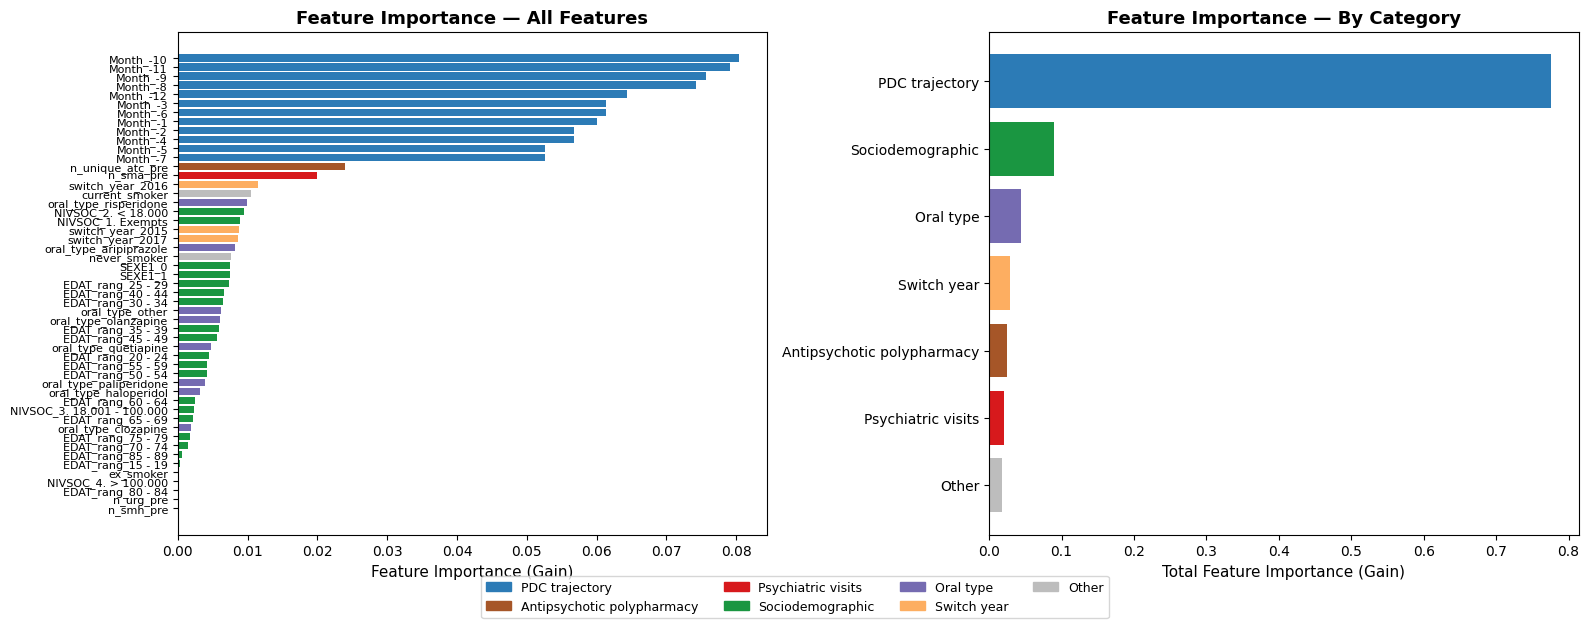

In [7]:
# ── 4.3 Plot all features ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Feature Importance (Gain)', fontsize=11)
axes[0].set_title('Feature Importance — All Features', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)

cat_importance = fi.groupby([categorize(f) for f in fi.index]).sum().sort_values(ascending=False)
axes[1].barh(cat_importance.index[::-1], cat_importance.values[::-1],
             color=[color_map[c] for c in cat_importance.index][::-1])
axes[1].set_xlabel('Total Feature Importance (Gain)', fontsize=11)
axes[1].set_title('Feature Importance — By Category', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=10)

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items() if k in categories]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('feature_importance_all.png', dpi=150, bbox_inches='tight')
plt.show()

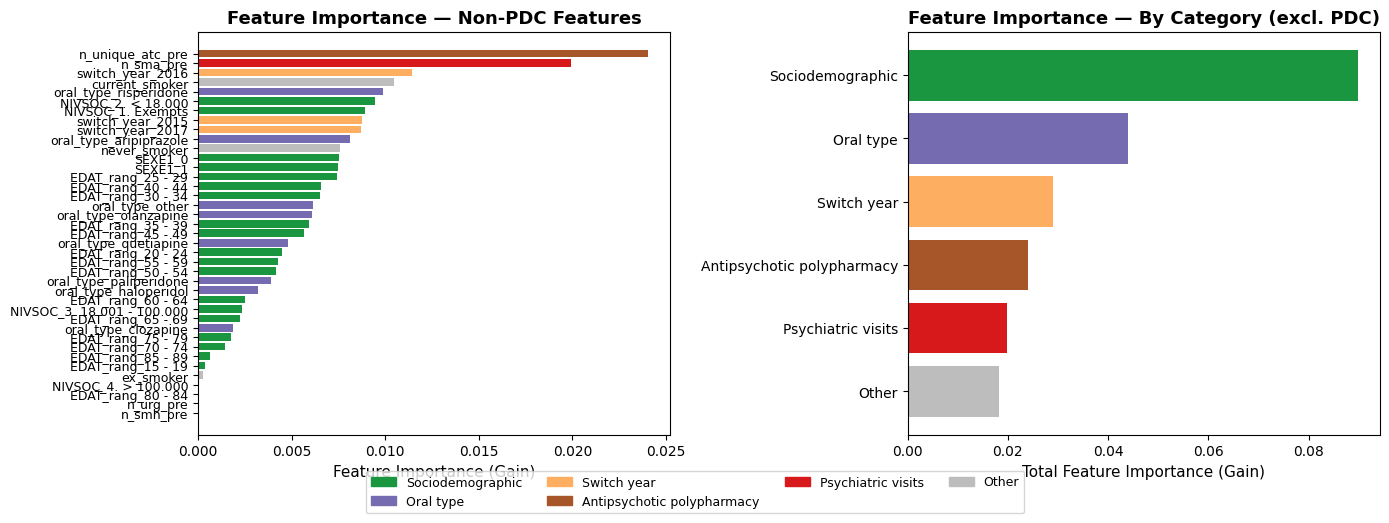

In [8]:
# ── 4.4 Plot non-PDC features only ────────────────────────────────────────────
fi_no_pdc = fi[~fi.index.str.startswith('Month_')]
cats_no_pdc = [categorize(f) for f in fi_no_pdc.index]
colors_no_pdc = [color_map[c] for c in cats_no_pdc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(fi_no_pdc.index[::-1], fi_no_pdc.values[::-1], color=colors_no_pdc[::-1])
axes[0].set_xlabel('Feature Importance (Gain)', fontsize=11)
axes[0].set_title('Feature Importance — Non-PDC Features', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=9)

cat_no_pdc = fi_no_pdc.groupby(cats_no_pdc).sum().sort_values(ascending=False)
axes[1].barh(cat_no_pdc.index[::-1], cat_no_pdc.values[::-1],
             color=[color_map[c] for c in cat_no_pdc.index][::-1])
axes[1].set_xlabel('Total Feature Importance (Gain)', fontsize=11)
axes[1].set_title('Feature Importance — By Category (excl. PDC)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=10)

patches = [mpatches.Patch(color=color_map[c], label=c) for c in cat_no_pdc.index]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('feature_importance_no_pdc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. SHAP Analysis (Non-PDC Features)

SHAP values are computed using a Random Forest trained only on non-PDC features, to isolate the contribution of clinical and sociodemographic variables independently of the dominant PDC signal.

SHAP values shape: (1025, 39, 4)


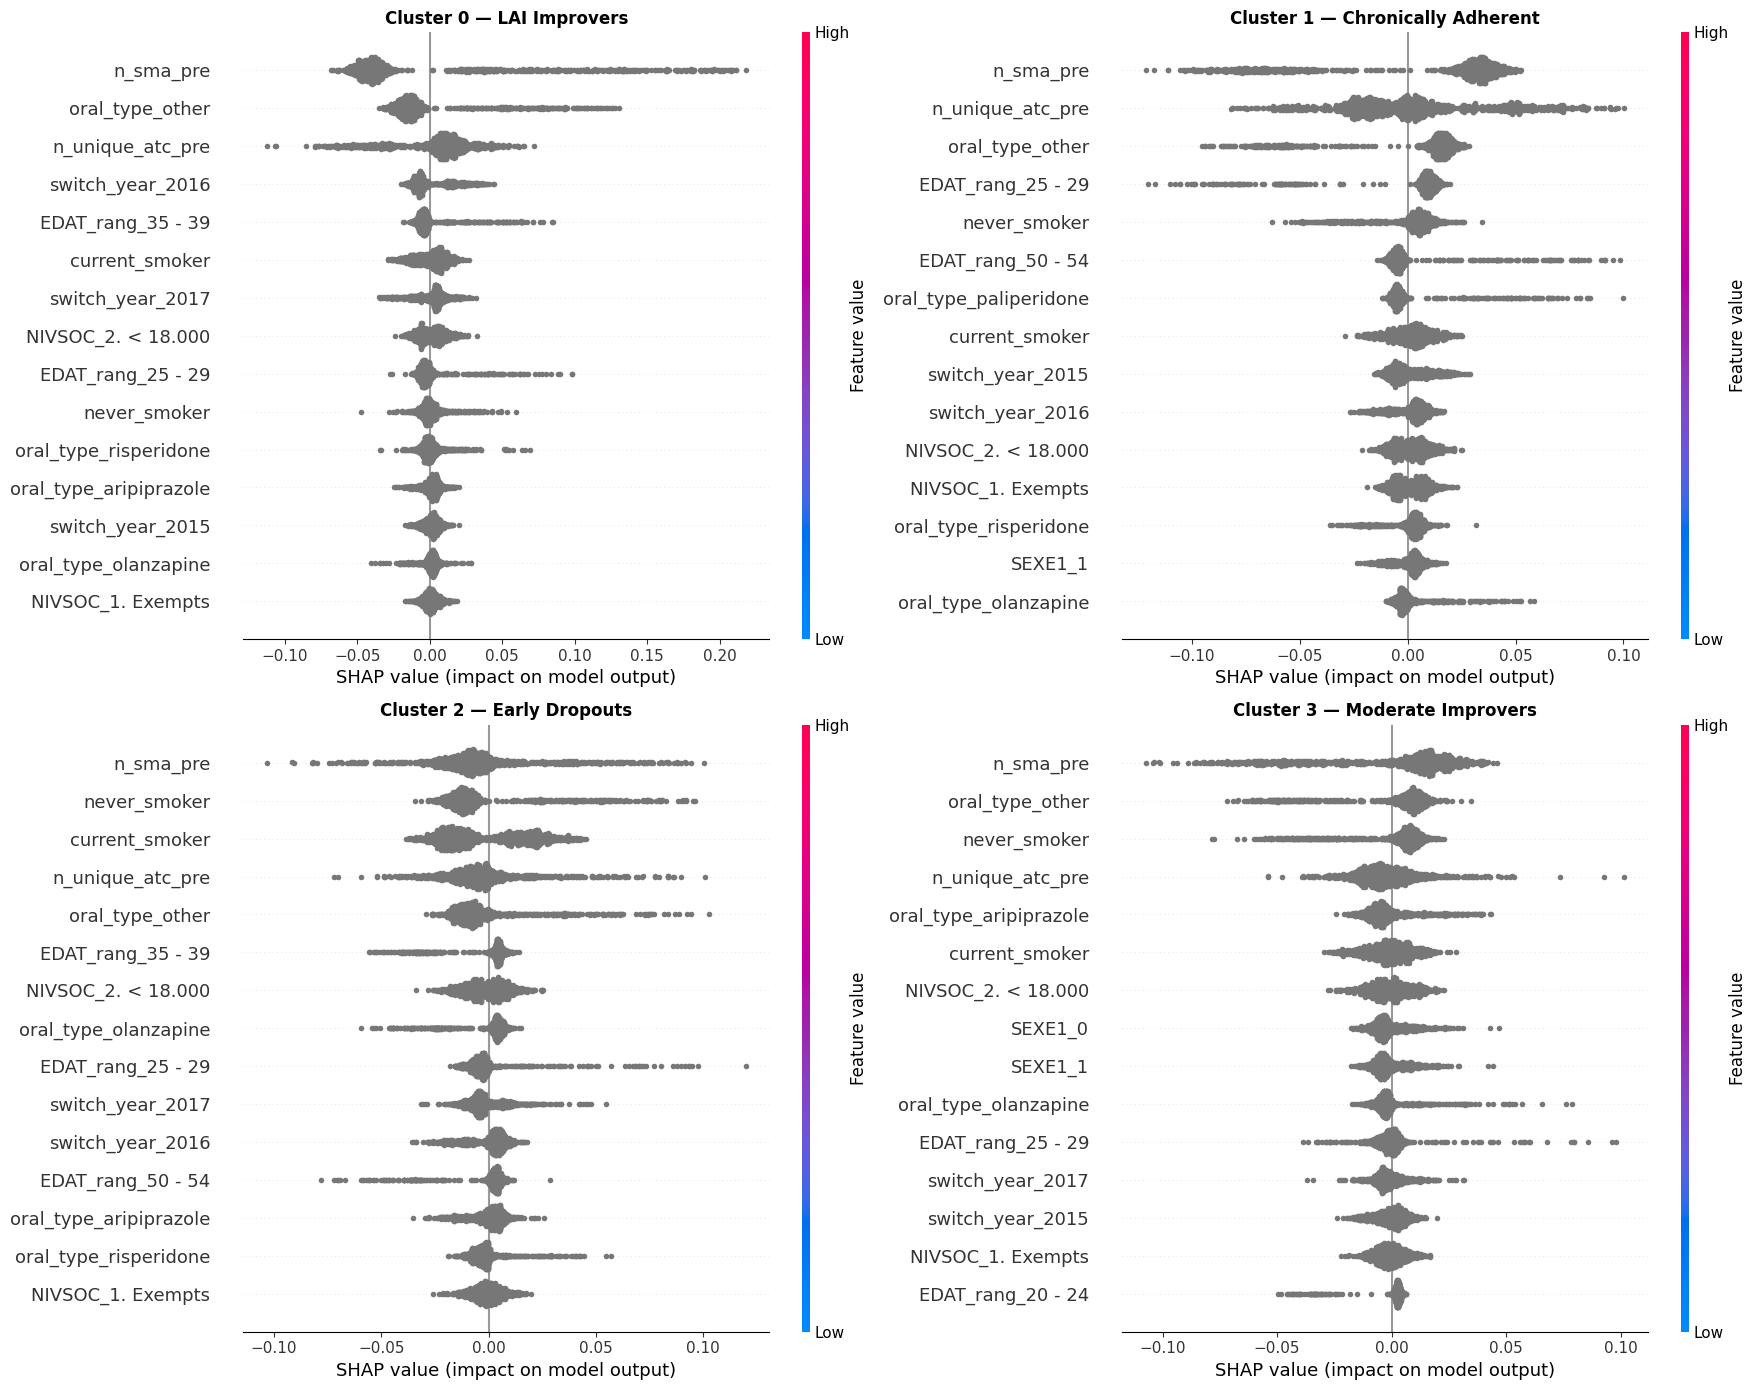

In [9]:
# ── 5.1 Train RF on non-PDC features only ─────────────────────────────────────
non_pdc_cols = [c for c in X.columns if not c.startswith('Month_')]
X_no_pdc = pd.DataFrame(X_arr, columns=X.columns.tolist())[non_pdc_cols]

rf_no_pdc = RandomForestClassifier(
    n_estimators=200, max_depth=9,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_no_pdc.fit(X_no_pdc.values, y_arr)

# ── 5.2 Compute SHAP values ───────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf_no_pdc)
shap_values = explainer.shap_values(X_no_pdc)
# shap_values shape: (n_samples, n_features, n_classes)

print(f"SHAP values shape: {np.array(shap_values).shape}")

# ── 5.3 Beeswarm plots per cluster ────────────────────────────────────────────
cluster_names = {
    0: 'Cluster 0 — LAI Improvers',
    1: 'Cluster 1 — Chronically Adherent',
    2: 'Cluster 2 — Early Dropouts',
    3: 'Cluster 3 — Moderate Improvers'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (cluster_id, name) in enumerate(cluster_names.items()):
    shap_cluster = shap_values[:, :, cluster_id]
    plt.sca(axes[i])
    shap.summary_plot(
        shap_cluster, X_no_pdc,
        show=False, plot_size=None, max_display=15
    )
    axes[i].set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. PDC Trajectory Plots by Drug Type and Cluster

lai_type
paliperidone    563
aripiprazole    336
risperidone     113
olanzapine       13
Name: count, dtype: int64


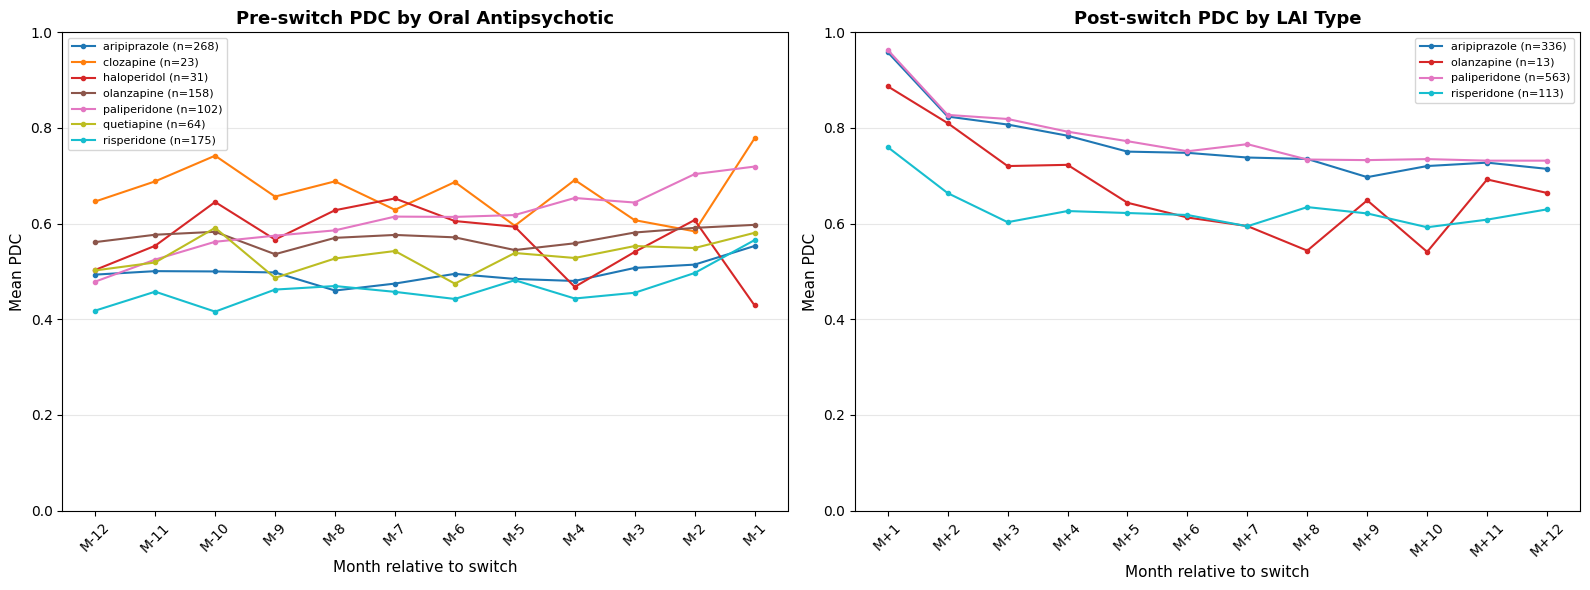

In [10]:
# ── 6.1 Get correct LAI types from t23 + t25 ─────────────────────────────────
def classify_lai(name):
    name = str(name).upper()
    if 'XEPLION' in name or 'TREVICTA' in name or 'INVEGA' in name: return 'paliperidone'
    elif 'ABILIFY MAINTENA' in name:                                  return 'aripiprazole'
    elif 'RISPERDAL CONSTA' in name:                                  return 'risperidone'
    elif 'ZYPADHERA' in name:                                         return 'olanzapine'
    elif 'HALDOL' in name and ('DECANOATE' in name or 'DEPOT' in name): return 'haloperidol'
    else:                                                              return 'other'

lai_products_t23 = ['ABILIFY MAINTENA', 'XEPLION', 'RISPERDAL CONSTA', 'TREVICTA', 'INVEGA']
t23_lai = t23[t23['idCas'].isin(pdc['idCas'])].copy()
mask = t23_lai['DES_HIS_Producte'].str.upper().apply(
    lambda x: any(p in x for p in lai_products_t23)
)
t23_lai = t23_lai[mask][['idCas', 'Any_Mes', 'DES_HIS_Producte']]
t23_lai.columns = ['idCas', 'Any_Mes', 'first_lai_product']

t25_ap = t25[t25['(HIS) Subgrup 7 (ATC)'].str.startswith('N05A', na=False)]
t25_lai = t25_ap[t25_ap['idCas'].isin(pdc['idCas'])][['idCas', 'Any_Mes', '(HIS) Producte Desc']].copy()
t25_lai.columns = ['idCas', 'Any_Mes', 'first_lai_product']

all_lai = pd.concat([t23_lai, t25_lai], ignore_index=True)
all_lai = all_lai.merge(switch_dates, on='idCas', how='inner')
all_lai = all_lai[
    (all_lai['Any_Mes'] >= all_lai['first_lai_date'] - pd.DateOffset(months=1)) &
    (all_lai['Any_Mes'] <= all_lai['first_lai_date'] + pd.DateOffset(months=3))
]
first_lai = (
    all_lai.sort_values('Any_Mes')
    .groupby('idCas').first()
    .reset_index()[['idCas', 'first_lai_product']]
)
first_lai['lai_type'] = first_lai['first_lai_product'].apply(classify_lai)
print(first_lai['lai_type'].value_counts())

# ── 6.2 Build plot dataframe ──────────────────────────────────────────────────
plot_df = pdc[['idCas', 'cluster_k4'] + pre_cols + post_cols].copy()
plot_df = plot_df.merge(most_common_oral[['idCas', 'oral_type']], on='idCas', how='left')
plot_df = plot_df.merge(first_lai[['idCas', 'lai_type']], on='idCas', how='left')

oral_types = sorted([o for o in plot_df['oral_type'].dropna().unique() if o != 'other'])
lai_types  = sorted([l for l in plot_df['lai_type'].dropna().unique()  if l != 'other'])
month_labels_pre  = [f'M{i}' for i in range(-12, 0)]
month_labels_post = [f'M+{i}' for i in range(1, 13)]

# ── 6.3 Overall: oral pre-switch and LAI post-switch ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_oral = cm.tab10(np.linspace(0, 1, len(oral_types)))
colors_lai  = cm.tab10(np.linspace(0, 1, len(lai_types)))

for oral, color in zip(oral_types, colors_oral):
    subset = plot_df[plot_df['oral_type'] == oral]
    axes[0].plot(month_labels_pre, subset[pre_cols].mean().values,
                 marker='o', markersize=3, label=f'{oral} (n={len(subset)})', color=color)
axes[0].set_title('Pre-switch PDC by Oral Antipsychotic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month relative to switch', fontsize=11)
axes[0].set_ylabel('Mean PDC', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

for lai, color in zip(lai_types, colors_lai):
    subset = plot_df[plot_df['lai_type'] == lai]
    axes[1].plot(month_labels_post, subset[post_cols].mean().values,
                 marker='o', markersize=3, label=f'{lai} (n={len(subset)})', color=color)
axes[1].set_title('Post-switch PDC by LAI Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month relative to switch', fontsize=11)
axes[1].set_ylabel('Mean PDC', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pdc_trajectory_by_drug.png', dpi=150, bbox_inches='tight')
plt.show()

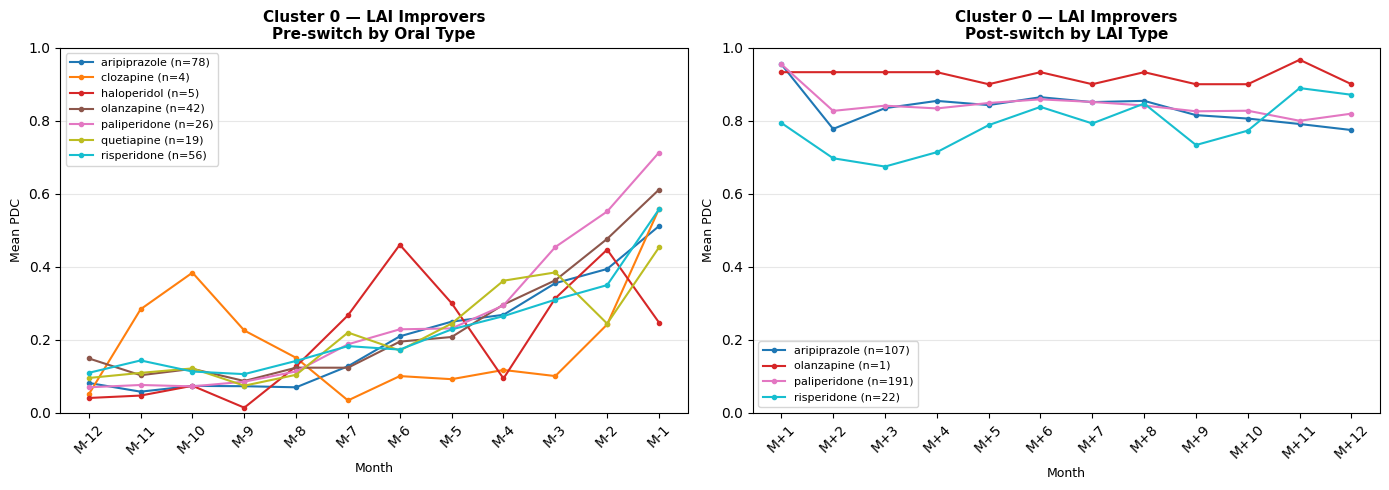

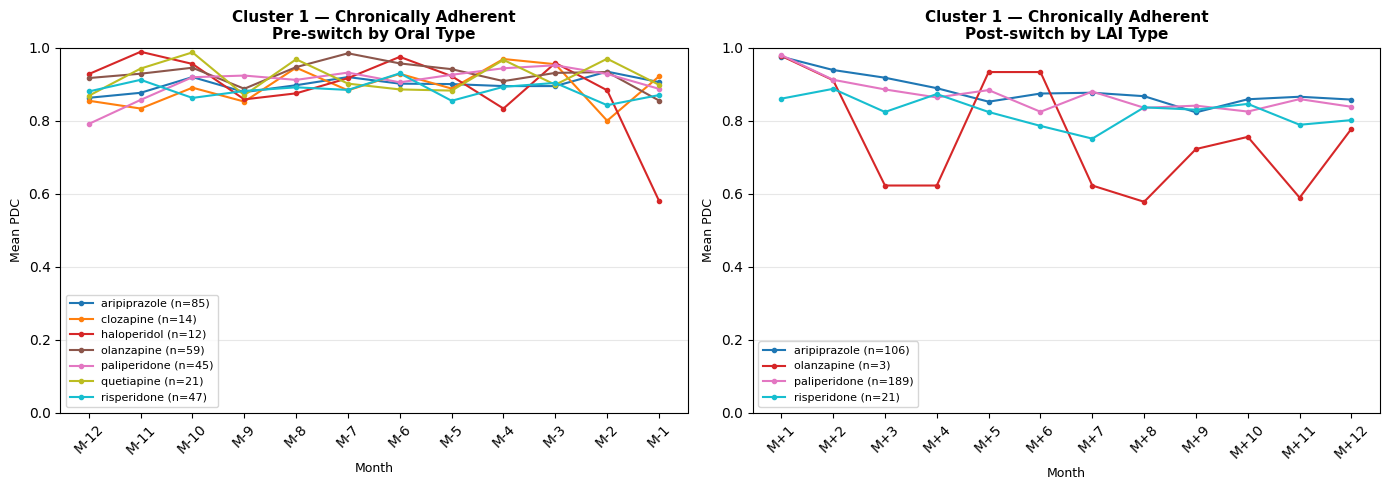

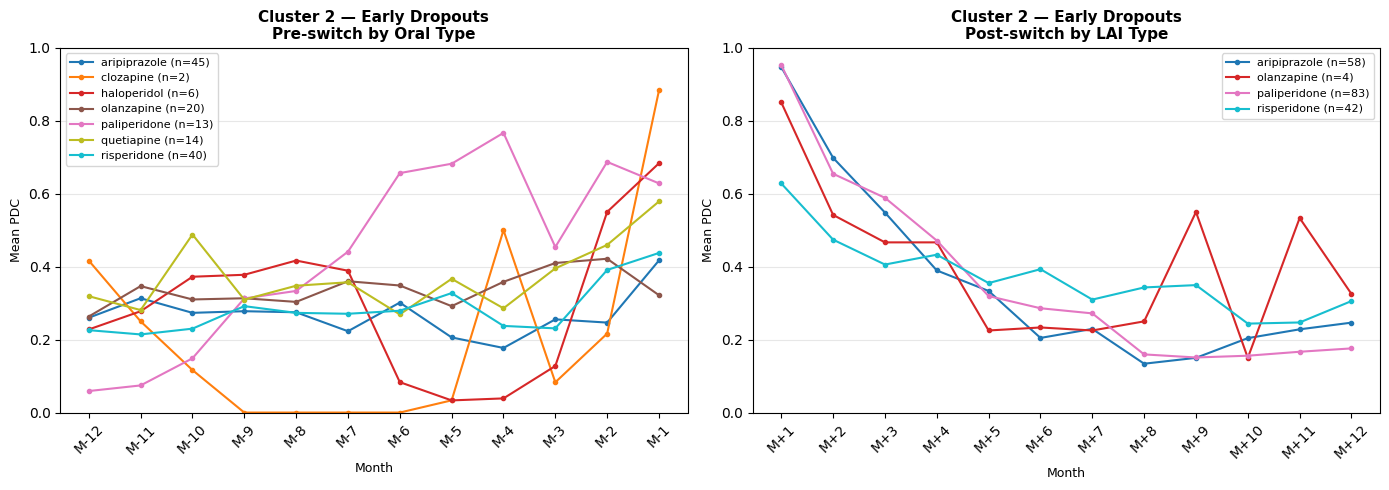

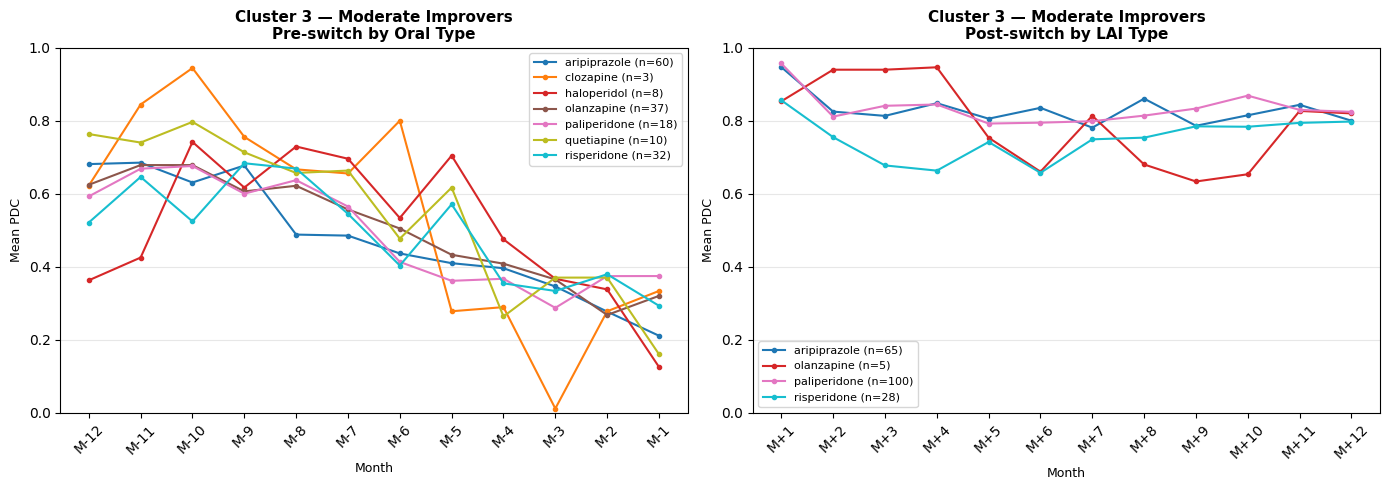

In [12]:
cluster_labels = {
    0: 'Cluster 0 — LAI Improvers',
    1: 'Cluster 1 — Chronically Adherent',
    2: 'Cluster 2 — Early Dropouts',
    3: 'Cluster 3 — Moderate Improvers'
}

for cluster_id, cluster_name in cluster_labels.items():
    cs = plot_df[plot_df['cluster_k4'] == cluster_id]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for oral, color in zip(oral_types, cm.tab10(np.linspace(0, 1, len(oral_types)))):
        subset = cs[cs['oral_type'] == oral]
        if len(subset) == 0: continue
        axes[0].plot(month_labels_pre, subset[pre_cols].mean().values,
                     marker='o', markersize=3, label=f'{oral} (n={len(subset)})', color=color)
    axes[0].set_title(f'{cluster_name}\nPre-switch by Oral Type', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Month', fontsize=9)
    axes[0].set_ylabel('Mean PDC', fontsize=9)
    axes[0].set_ylim(0, 1)
    axes[0].legend(fontsize=8)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

    for lai, color in zip(lai_types, cm.tab10(np.linspace(0, 1, len(lai_types)))):
        subset = cs[cs['lai_type'] == lai]
        if len(subset) == 0: continue
        axes[1].plot(month_labels_post, subset[post_cols].mean().values,
                     marker='o', markersize=3, label=f'{lai} (n={len(subset)})', color=color)
    axes[1].set_title(f'{cluster_name}\nPost-switch by LAI Type', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Month', fontsize=9)
    axes[1].set_ylabel('Mean PDC', fontsize=9)
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'pdc_cluster_{cluster_id}.png', dpi=200, bbox_inches='tight')
    plt.show()

---
## 7. Prospective Application to Oral-Only Non-Switcher Patients

In [13]:
# ── 7.1 Identify non-switchers ────────────────────────────────────────────────
non_switchers = annual[annual['oral_only'] == True][['idCas']].drop_duplicates()
print(f"Non-switchers: {len(non_switchers)}")

# ── 7.2 Calculate 12-month pre-reference PDC ──────────────────────────────────
t23_ns = t23[t23['idCas'].isin(non_switchers['idCas'])][[
    'idCas', 'Any_Mes', 'Nombre_DDD_Receptes_Dispensades'
]].copy()

last_date = t23_ns.groupby('idCas')['Any_Mes'].max().reset_index()
last_date.columns = ['idCas', 'ref_date']

t23_ns = t23_ns.merge(last_date, on='idCas', how='left')
t23_ns_12 = t23_ns[
    (t23_ns['Any_Mes'] > t23_ns['ref_date'] - pd.DateOffset(months=12)) &
    (t23_ns['Any_Mes'] <= t23_ns['ref_date'])
].copy()
t23_ns_12['Nombre_DDD_Receptes_Dispensades'] = pd.to_numeric(
    t23_ns_12['Nombre_DDD_Receptes_Dispensades'], errors='coerce'
).fillna(0)

def calc_monthly_pdc(df):
    records = []
    for idCas, patient_df in df.groupby('idCas'):
        ref = patient_df['ref_date'].iloc[0]
        months = pd.date_range(end=ref, periods=12, freq='MS')
        carry = 0
        pdc_months = []
        for month_start in months:
            days_in_month = (month_start + pd.offsets.MonthEnd(1) - month_start).days
            dispensings = patient_df[patient_df['Any_Mes'] == month_start]
            days_covered = float(carry + dispensings['Nombre_DDD_Receptes_Dispensades'].sum())
            pdc = min(days_covered / days_in_month, 1.0)
            carry = max(days_covered - days_in_month, 0)
            pdc_months.append(pdc)
        records.append({'idCas': idCas, **{f'Month_{i-12}': pdc_months[i] for i in range(12)}})
    return pd.DataFrame(records)

print("Calculating PDC for non-switchers...")
pdc_ns = calc_monthly_pdc(t23_ns_12)
print(f"Done. Shape: {pdc_ns.shape}")

pre_cols_ns = [f'Month_{i}' for i in range(-12, 0)]
mean_pdc_ns = pdc_ns[pre_cols_ns].mean(axis=1)
print(f"\nMean PDC distribution:\n{mean_pdc_ns.describe()}")
print(f"Patients with mean PDC == 0: {(mean_pdc_ns == 0).sum()}")

Non-switchers: 5662
Calculating PDC for non-switchers...
Done. Shape: (5662, 13)

Mean PDC distribution:
count    5662.000000
mean        0.612238
std         0.401000
min         0.000000
25%         0.166667
50%         0.800000
75%         1.000000
max         1.000000
dtype: float64
Patients with mean PDC == 0: 858


In [14]:
# ── 7.3 Build non-switcher feature matrix ─────────────────────────────────────
features_ns = pdc_ns.copy()

# Sociodemographics
features_ns = features_ns.merge(
    socio[['idCas', 'SEXE1', 'EDAT_rang', 'NIVSOC']], on='idCas', how='left'
)

# Oral type
t23_ns_full = t23[t23['idCas'].isin(non_switchers['idCas'])].copy()
most_common_oral_ns = (
    t23_ns_full.groupby(['idCas', 'DES_HIS_Producte'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates('idCas')[['idCas', 'DES_HIS_Producte']]
)
most_common_oral_ns.columns = ['idCas', 'main_oral_product']
most_common_oral_ns['oral_type'] = most_common_oral_ns['main_oral_product'].apply(classify_oral)
features_ns = features_ns.merge(most_common_oral_ns[['idCas', 'oral_type']], on='idCas', how='left')

# Visit counts using last date as reference
ref_dates_ns = last_date.rename(columns={'ref_date': 'first_lai_date'})
urg_counts_ns = count_preswitch_visits(urg, 'dat_ini', ref_dates_ns, 'urg')
smh_counts_ns = count_preswitch_visits(smh, 'dat_ini', ref_dates_ns, 'smh')
sma_counts_ns = count_preswitch_visits(sma, 'dat_ini', ref_dates_ns, 'sma')
for counts in [urg_counts_ns, smh_counts_ns, sma_counts_ns]:
    features_ns = features_ns.merge(counts, on='idCas', how='left')
features_ns[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']] = \
    features_ns[['n_urg_pre', 'n_smh_pre', 'n_sma_pre']].fillna(0)

# Polypharmacy
polypharmacy_ns = (
    t23_ns_full.groupby('idCas')['ID_HIS_Subgrup_7_ATC']
    .nunique().reset_index(name='n_unique_atc_pre')
)
features_ns = features_ns.merge(polypharmacy_ns, on='idCas', how='left')
features_ns['n_unique_atc_pre'] = features_ns['n_unique_atc_pre'].fillna(0)

# Impute switch year (most common in training cohort)
most_common_year = switch_info['switch_year'].mode()[0]
features_ns['switch_year'] = most_common_year

# Encode categoricals
features_ns_enc = pd.get_dummies(
    features_ns, columns=['SEXE1', 'EDAT_rang', 'NIVSOC', 'oral_type', 'switch_year']
)

# Align columns with training set
X_ns = features_ns_enc.drop(columns=['idCas'], errors='ignore')
for col in X.columns:
    if col not in X_ns.columns:
        X_ns[col] = 0
X_ns = X_ns[X.columns]

print(f"Non-switcher feature matrix: {X_ns.shape}")
print(f"Missing values: {X_ns.isnull().sum().sum()}")

Non-switcher feature matrix: (5662, 51)
Missing values: 0


In [15]:
# ── 7.4 Predict and save ──────────────────────────────────────────────────────
y_pred_ns  = final_pipe.predict(X_ns.values)
y_proba_ns = final_pipe.predict_proba(X_ns.values)

results_ns = features_ns[['idCas']].copy()
results_ns['predicted_cluster'] = y_pred_ns
results_ns['prob_LAI_improver'] = y_proba_ns[:, 0]
results_ns['predicted_improver'] = (y_pred_ns == 0).astype(int)

print(f"Predicted cluster distribution:")
print(results_ns['predicted_cluster'].value_counts().sort_index())
print(f"\nPredicted LAI Improvers: {results_ns['predicted_improver'].sum()} "
      f"({100*results_ns['predicted_improver'].mean():.1f}%)")

results_ns.to_csv('nonswitcher_predictions.csv', index=False)
print("\nSaved to nonswitcher_predictions.csv")

Predicted cluster distribution:
predicted_cluster
0    1455
1    3094
2     737
3     376
Name: count, dtype: int64

Predicted LAI Improvers: 1455 (25.7%)

Saved to nonswitcher_predictions.csv


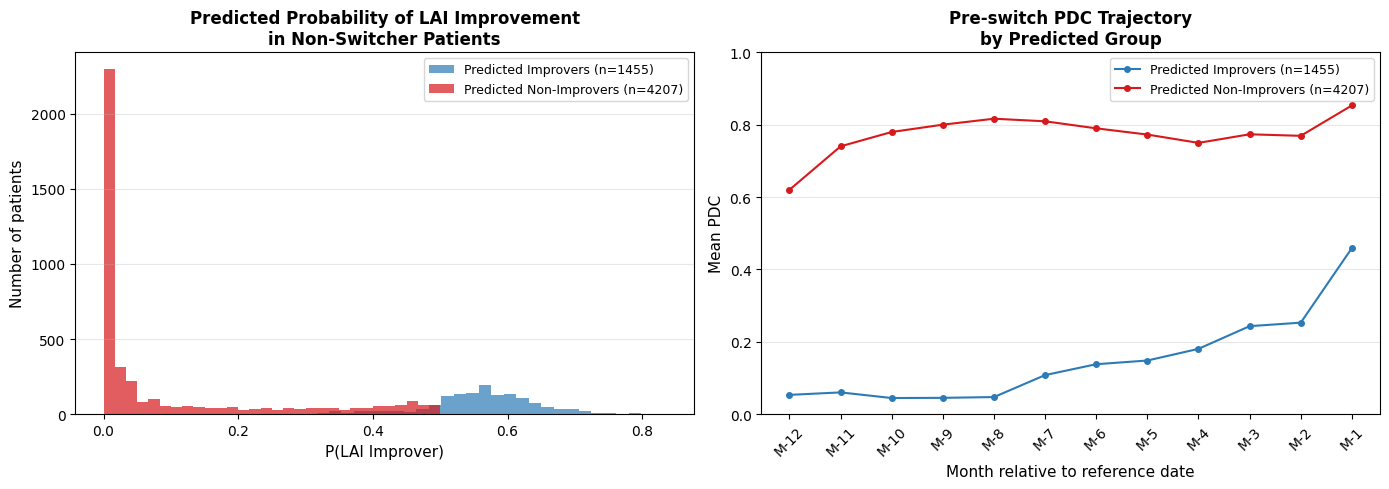

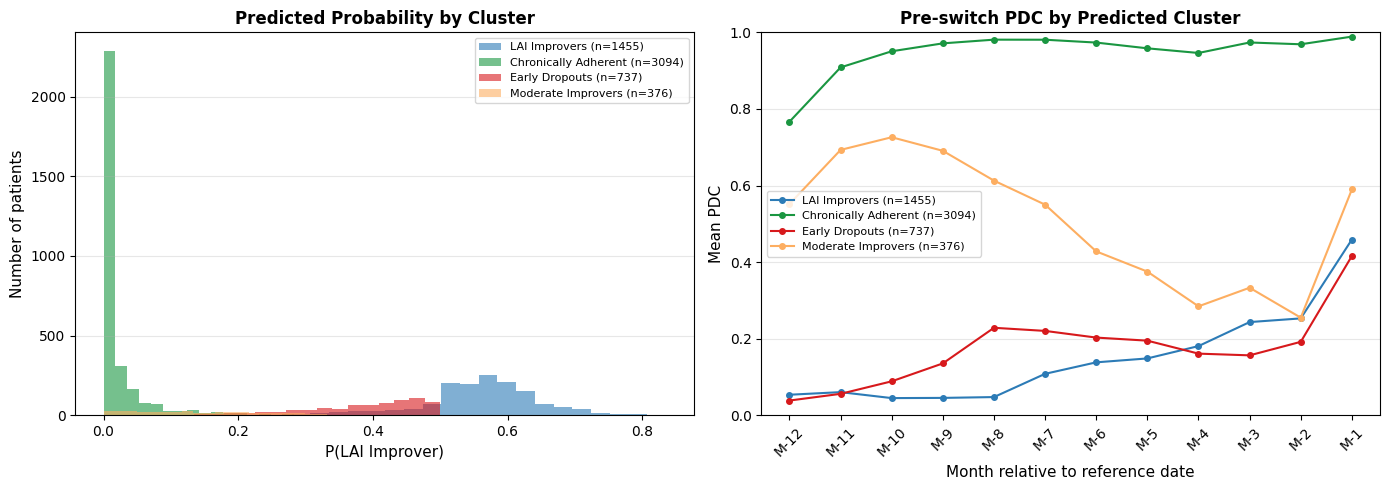

In [16]:
# ── 7.5 Plots: probability distribution + PDC trajectory by predicted cluster ─
plot_ns = pdc_ns.merge(
    results_ns[['idCas', 'predicted_cluster', 'prob_LAI_improver', 'predicted_improver']],
    on='idCas', how='left'
)

cluster_names_short = {
    0: 'LAI Improvers',
    1: 'Chronically Adherent',
    2: 'Early Dropouts',
    3: 'Moderate Improvers'
}
colors_clusters = {0: '#2c7bb6', 1: '#1a9641', 2: '#d7191c', 3: '#fdae61'}

# Plot 1: Binary improver vs non-improver
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
predicted_improvers = results_ns['predicted_improver'].astype(bool)

axes[0].hist(plot_ns[plot_ns['predicted_improver'] == 1]['prob_LAI_improver'],
             bins=30, alpha=0.7, color='#2c7bb6',
             label=f'Predicted Improvers (n={predicted_improvers.sum()})')
axes[0].hist(plot_ns[plot_ns['predicted_improver'] == 0]['prob_LAI_improver'],
             bins=30, alpha=0.7, color='#d7191c',
             label=f'Predicted Non-Improvers (n={(~predicted_improvers).sum()})')
axes[0].set_xlabel('P(LAI Improver)', fontsize=11)
axes[0].set_ylabel('Number of patients', fontsize=11)
axes[0].set_title('Predicted Probability of LAI Improvement\nin Non-Switcher Patients',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

for group, label, color in [
    (plot_ns[plot_ns['predicted_improver'] == 1], f'Predicted Improvers (n={predicted_improvers.sum()})', '#2c7bb6'),
    (plot_ns[plot_ns['predicted_improver'] == 0], f'Predicted Non-Improvers (n={(~predicted_improvers).sum()})', '#d7191c')
]:
    axes[1].plot(month_labels_pre, group[pre_cols_ns].mean().values,
                 marker='o', markersize=4, label=label, color=color)
axes[1].set_title('Pre-switch PDC Trajectory\nby Predicted Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month relative to reference date', fontsize=11)
axes[1].set_ylabel('Mean PDC', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nonswitcher_binary.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: By predicted cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cluster_id, name in cluster_names_short.items():
    subset = plot_ns[plot_ns['predicted_cluster'] == cluster_id]
    axes[0].hist(subset['prob_LAI_improver'], bins=20, alpha=0.6,
                 color=colors_clusters[cluster_id], label=f'{name} (n={len(subset)})')
axes[0].set_xlabel('P(LAI Improver)', fontsize=11)
axes[0].set_ylabel('Number of patients', fontsize=11)
axes[0].set_title('Predicted Probability by Cluster', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

for cluster_id, name in cluster_names_short.items():
    subset = plot_ns[plot_ns['predicted_cluster'] == cluster_id]
    if len(subset) == 0: continue
    axes[1].plot(month_labels_pre, subset[pre_cols_ns].mean().values,
                 marker='o', markersize=4, color=colors_clusters[cluster_id],
                 label=f'{name} (n={len(subset)})')
axes[1].set_title('Pre-switch PDC by Predicted Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month relative to reference date', fontsize=11)
axes[1].set_ylabel('Mean PDC', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nonswitcher_clusters.png', dpi=150, bbox_inches='tight')
plt.show()